# Construction Project Performance Analytics

## Project Objective

This project analyzes construction project performance using synthetic
project data.

The objective is to understand how actual project progress compares
with planned progress and identify areas of schedule and cost deviation.

### Key Business Questions

1. How closely does actual progress track planned progress?
2. Which work categories experience the highest delays?
3. Where are the largest cost variances occurring?
4. How does project performance change over time?
5. Which contractors show better schedule and cost performance?

### Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- SciPy

### Approach

The analysis will follow a typical data analytics workflow:

**Data Generation → Data Cleaning → Exploratory Analysis →
Feature Engineering → Statistical Analysis → Visualization → Insights**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

# Project directories
PROJECT_ROOT = Path.cwd().parent
VISUALIZATION_DIR = PROJECT_ROOT / "visualizations"

# Create visualization directory if needed
VISUALIZATION_DIR.mkdir(parents=True, exist_ok=True)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

print("Libraries imported successfully.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Visualization directory: {VISUALIZATION_DIR}")

Libraries imported successfully.
Project root: /Users/ananthrb/Desktop/construction-project-analytics
Visualization directory: /Users/ananthrb/Desktop/construction-project-analytics/visualizations


In [2]:
# Project-level information
project_details = {
    "Healthcare Facility": {
        "contract_value_cr": 28.50,
        "contractor": "Contractor A"
    },
    "Road Development": {
        "contract_value_cr": 46.75,
        "contractor": "Contractor B"
    },
    "Educational Campus": {
        "contract_value_cr": 18.20,
        "contractor": "Contractor C"
    },
    "Food & Commercial Facility": {
        "contract_value_cr": 9.80,
        "contractor": "Contractor A"
    },
    "Administrative Complex": {
        "contract_value_cr": 35.40,
        "contractor": "Contractor B"
    }
}

# Work-package cost allocation (% of contract value)
work_category_weights = {
    "Earthwork": 0.04,
    "RCC": 0.25,
    "Masonry": 0.10,
    "Plastering": 0.07,
    "Flooring": 0.06,
    "Electrical": 0.15,
    "Plumbing": 0.07,
    "HVAC": 0.12,
    "Fire Fighting": 0.05,
    "Other": 0.09
}

# Reporting period
months = pd.date_range(
    start="2025-01-01",
    periods=12,
    freq="MS"
)

print("Projects:", len(project_details))
print("Work packages:", len(work_category_weights))
print("Reporting months:", len(months))

Projects: 5
Work packages: 10
Reporting months: 12


In [3]:
total_weight = sum(work_category_weights.values())

print(f"Total allocation: {total_weight:.0%}")

Total allocation: 100%


In [4]:
# Work-package cost efficiency factors
# > 1.00 = cost pressure
# < 1.00 = cost efficiency

category_cost_factors = {
    "Earthwork": 1.02,
    "RCC": 1.06,
    "Masonry": 1.03,
    "Plastering": 1.01,
    "Flooring": 0.99,
    "Electrical": 1.05,
    "Plumbing": 1.04,
    "HVAC": 1.08,
    "Fire Fighting": 1.02,
    "Other": 1.00
}

In [5]:
# Set a seed so the synthetic dataset is reproducible
np.random.seed(42)

records = []

# Project-specific performance assumptions
project_performance = {
    "Healthcare Facility": {
        "progress_factor": 0.94,
        "cost_factor": 1.04,
        "delay_factor": 1.10
    },
    "Road Development": {
        "progress_factor": 1.02,
        "cost_factor": 0.98,
        "delay_factor": 0.80
    },
    "Educational Campus": {
        "progress_factor": 1.05,
        "cost_factor": 0.97,
        "delay_factor": 0.70
    },
    "Food & Commercial Facility": {
        "progress_factor": 0.91,
        "cost_factor": 1.06,
        "delay_factor": 1.20
    },
    "Administrative Complex": {
        "progress_factor": 0.88,
        "cost_factor": 1.00,
        "delay_factor": 1.30
    }
}

# Generate monthly observations
for project, details in project_details.items():
    
    contract_value = details["contract_value_cr"]
    contractor = details["contractor"]
    
    performance = project_performance[project]
    
    for category, weight in work_category_weights.items():
        
        category_budget = contract_value * weight
        
        for month_number, month in enumerate(months, start=1):
            
            # Planned cumulative progress
            planned_progress = min(
                100,
                (month_number / len(months)) * 100
            )
            
            # Actual progress with project-specific performance
            progress_noise = np.random.normal(0, 3)
            
            actual_progress = (
                planned_progress
                * performance["progress_factor"]
                + progress_noise
            )
            
            actual_progress = np.clip(
                actual_progress,
                0,
                100
            )
            
            # Planned and actual cumulative cost
            planned_cost = (
                category_budget
                * planned_progress
                / 100
            )

            # Independent work-package cost pressure
            category_cost_factor = category_cost_factors[category]

            cost_noise = np.random.normal(0, 0.02)

            actual_cost = (
                category_budget
                * actual_progress
                / 100
                * performance["cost_factor"]
                * category_cost_factor
                * (1 + cost_noise)
            )
            
            
            actual_cost = max(actual_cost, 0)
            
            # Delay in days
            delay_days = max(
                0,
                int(
                    np.random.normal(
                        5 * performance["delay_factor"],
                        3
                    )
                )
            )
            
            records.append({
                "project_name": project,
                "contractor": contractor,
                "month": month,
                "work_category": category,
                "contract_value_cr": contract_value,
                "budget_cr": category_budget,
                "planned_progress_pct": planned_progress,
                "actual_progress_pct": actual_progress,
                "planned_cost_cr": planned_cost,
                "actual_cost_cr": actual_cost,
                "delay_days": delay_days
            })

# Create DataFrame
df = pd.DataFrame(records)

print("Dataset created successfully.")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")

Dataset created successfully.
Rows: 600
Columns: 11


In [6]:
df.head()

,project_name,contractor,month,work_category,contract_value_cr,budget_cr,planned_progress_pct,actual_progress_pct,planned_cost_cr,actual_cost_cr,delay_days
0,Healthcare Facility,Contractor A,2025-01-01,Earthwork,28.50,1.14,8.33,9.32,0.10,0.11,7
1,Healthcare Facility,Contractor A,2025-02-01,Earthwork,28.50,1.14,16.67,20.24,0.19,0.24,4
2,Healthcare Facility,Contractor A,2025-03-01,Earthwork,28.50,1.14,25.00,28.24,0.29,0.35,4
3,Healthcare Facility,Contractor A,2025-04-01,Earthwork,28.50,1.14,33.33,32.96,0.38,0.39,4
4,Healthcare Facility,Contractor A,2025-05-01,Earthwork,28.50,1.14,41.67,39.89,0.48,0.46,0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   project_name          600 non-null    str           
 1   contractor            600 non-null    str           
 2   month                 600 non-null    datetime64[us]
 3   work_category         600 non-null    str           
 4   contract_value_cr     600 non-null    float64       
 5   budget_cr             600 non-null    float64       
 6   planned_progress_pct  600 non-null    float64       
 7   actual_progress_pct   600 non-null    float64       
 8   planned_cost_cr       600 non-null    float64       
 9   actual_cost_cr        600 non-null    float64       
 10  delay_days            600 non-null    int64         
dtypes: datetime64[us](1), float64(6), int64(1), str(3)
memory usage: 51.7 KB


In [8]:
print("Missing values:")
print(df.isna().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
project_name            0
contractor              0
month                   0
work_category           0
contract_value_cr       0
budget_cr               0
planned_progress_pct    0
actual_progress_pct     0
planned_cost_cr         0
actual_cost_cr          0
delay_days              0
dtype: int64

Duplicate rows:
0


In [9]:
# Work-package schedule profiles
# start_month = month when meaningful work begins
# duration = approximate number of months to reach completion

work_profiles = {
    "Earthwork": {
        "start_month": 1,
        "duration": 4
    },
    "RCC": {
        "start_month": 1,
        "duration": 8
    },
    "Masonry": {
        "start_month": 3,
        "duration": 7
    },
    "Plastering": {
        "start_month": 5,
        "duration": 6
    },
    "Flooring": {
        "start_month": 7,
        "duration": 5
    },
    "Electrical": {
        "start_month": 4,
        "duration": 8
    },
    "Plumbing": {
        "start_month": 4,
        "duration": 8
    },
    "HVAC": {
        "start_month": 7,
        "duration": 5
    },
    "Fire Fighting": {
        "start_month": 6,
        "duration": 6
    },
    "Other": {
        "start_month": 1,
        "duration": 12
    }
}

print("Work-package profiles created:", len(work_profiles))

Work-package profiles created: 10


In [10]:
def calculate_planned_progress(month_number, start_month, duration):
    """
    Calculate cumulative planned progress for a work package.
    """
    
    if month_number < start_month:
        return 0
    
    elapsed_months = month_number - start_month + 1
    
    progress = (elapsed_months / duration) * 100
    
    return min(progress, 100)

In [11]:
# Regenerate dataset using realistic work-package schedules

np.random.seed(42)

records = []

for project, details in project_details.items():
    
    contract_value = details["contract_value_cr"]
    contractor = details["contractor"]
    performance = project_performance[project]
    
    for category, weight in work_category_weights.items():
        
        category_budget = contract_value * weight
        
        start_month = work_profiles[category]["start_month"]
        duration = work_profiles[category]["duration"]
        previous_actual_progress = 0

        for month_number, month in enumerate(months, start=1):
            
            # Planned cumulative progress
            planned_progress = calculate_planned_progress(
                month_number,
                start_month,
                duration
            )
            
            # Actual progress
            progress_noise = np.random.normal(0, 3)
            
            actual_progress = (
                planned_progress
                * performance["progress_factor"]
                + progress_noise
            )

            # Prevent actual cumulative progress from exceeding 100%
            actual_progress = np.clip(actual_progress, 0, 100)

            # Prevent actual progress before planned start
            if planned_progress == 0:
                actual_progress = 0

            # Keep cumulative actual progress non-decreasing
            actual_progress = max(
            previous_actual_progress,
            actual_progress
            )

            actual_progress = min(
                actual_progress,
                100
            )

            previous_actual_progress = actual_progress
            
            # Planned cost
            planned_cost = (
                category_budget
                * planned_progress
                / 100
            )

            # Actual cost
            # Cost performance is modelled independently from physical progress

            category_cost_factor = category_cost_factors[category]

            cost_noise = np.random.normal(0, 0.02)

            actual_cost = (
                 planned_cost
                * performance["cost_factor"]
                * category_cost_factor
                * (1 + cost_noise)
            )
            
            actual_cost = max(actual_cost, 0)
            
            # Delay
            delay_days = max(
                0,
                int(
                    np.random.normal(
                        5 * performance["delay_factor"],
                        3
                    )
                )
            )
            
            records.append({
                "project_name": project,
                "contractor": contractor,
                "month": month,
                "work_category": category,
                "contract_value_cr": contract_value,
                "budget_cr": category_budget,
                "planned_progress_pct": planned_progress,
                "actual_progress_pct": actual_progress,
                "planned_cost_cr": planned_cost,
                "actual_cost_cr": actual_cost,
                "delay_days": delay_days
            })

# Create DataFrame
df = pd.DataFrame(records)

print("Dataset regenerated successfully.")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")

Dataset regenerated successfully.
Rows: 600
Columns: 11


In [12]:
for month in range(1, 13):
    progress = calculate_planned_progress(
        month,
        start_month=3,
        duration=7
    )
    
    print(f"Month {month}: {progress:.1f}%")

Month 1: 0.0%
Month 2: 0.0%
Month 3: 14.3%
Month 4: 28.6%
Month 5: 42.9%
Month 6: 57.1%
Month 7: 71.4%
Month 8: 85.7%
Month 9: 100.0%
Month 10: 100.0%
Month 11: 100.0%
Month 12: 100.0%


In [13]:
df.head()

,project_name,contractor,month,work_category,contract_value_cr,budget_cr,planned_progress_pct,actual_progress_pct,planned_cost_cr,actual_cost_cr,delay_days
0,Healthcare Facility,Contractor A,2025-01-01,Earthwork,28.50,1.14,25.00,24.99,0.29,0.30,7
1,Healthcare Facility,Contractor A,2025-02-01,Earthwork,28.50,1.14,50.00,51.57,0.57,0.60,4
2,Healthcare Facility,Contractor A,2025-03-01,Earthwork,28.50,1.14,75.00,75.24,0.86,0.92,4
3,Healthcare Facility,Contractor A,2025-04-01,Earthwork,28.50,1.14,100.00,95.63,1.14,1.20,4
4,Healthcare Facility,Contractor A,2025-05-01,Earthwork,28.50,1.14,100.00,95.63,1.14,1.16,0


In [14]:
df[
    ["project_name",
     "work_category",
     "month",
     "planned_progress_pct",
     "actual_progress_pct"]
].head(20)

,project_name,work_category,month,planned_progress_pct,actual_progress_pct
0,Healthcare Facility,Earthwork,2025-01-01,25.00,24.99
1,Healthcare Facility,Earthwork,2025-02-01,50.00,51.57
2,Healthcare Facility,Earthwork,2025-03-01,75.00,75.24
3,Healthcare Facility,Earthwork,2025-04-01,100.00,95.63
4,Healthcare Facility,Earthwork,2025-05-01,100.00,95.63
5,Healthcare Facility,Earthwork,2025-06-01,100.00,95.63
6,Healthcare Facility,Earthwork,2025-07-01,100.00,95.63
7,Healthcare Facility,Earthwork,2025-08-01,100.00,95.63
8,Healthcare Facility,Earthwork,2025-09-01,100.00,95.63
9,Healthcare Facility,Earthwork,2025-10-01,100.00,95.63


In [15]:
# Check whether cumulative actual progress ever decreases
progress_check = (
    df.sort_values(
        ["project_name", "work_category", "month"]
    )
    .groupby(["project_name", "work_category"])["actual_progress_pct"]
    .diff()
)

print("Negative progress changes:", (progress_check < 0).sum())

Negative progress changes: 0


In [16]:
# Calculate project performance KPIs

df["progress_variance_pct"] = (
    df["actual_progress_pct"]
    - df["planned_progress_pct"]
)

df["cost_variance_cr"] = (
    df["actual_cost_cr"]
    - df["planned_cost_cr"]
)

df["cost_variance_pct"] = np.where(
    df["planned_cost_cr"] > 0,
    (df["cost_variance_cr"] / df["planned_cost_cr"]) * 100,
    0
)

# Financial progress as a percentage of the total contract value
df["financial_progress_pct"] = (
    df["actual_cost_cr"]
    / df["contract_value_cr"]
) * 100

# Difference between physical and financial progress
df["physical_financial_gap_pct"] = (
    df["actual_progress_pct"]
    - df["financial_progress_pct"]
)

# Schedule status
df["schedule_status"] = np.where(
    df["progress_variance_pct"] >= 0,
    "On / Ahead",
    "Behind"
)

df.head()

,project_name,contractor,month,work_category,contract_value_cr,budget_cr,planned_progress_pct,actual_progress_pct,planned_cost_cr,actual_cost_cr,delay_days,progress_variance_pct,cost_variance_cr,cost_variance_pct,financial_progress_pct,physical_financial_gap_pct,schedule_status
0,Healthcare Facility,Contractor A,2025-01-01,Earthwork,28.50,1.14,25.00,24.99,0.29,0.30,7,-0.01,0.02,5.79,1.06,23.93,Behind
1,Healthcare Facility,Contractor A,2025-02-01,Earthwork,28.50,1.14,50.00,51.57,0.57,0.60,4,1.57,0.03,5.58,2.11,49.46,On / Ahead
2,Healthcare Facility,Contractor A,2025-03-01,Earthwork,28.50,1.14,75.00,75.24,0.86,0.92,4,0.24,0.07,7.71,3.23,72.01,On / Ahead
3,Healthcare Facility,Contractor A,2025-04-01,Earthwork,28.50,1.14,100.00,95.63,1.14,1.20,4,-4.37,0.06,5.10,4.20,91.42,Behind
4,Healthcare Facility,Contractor A,2025-05-01,Earthwork,28.50,1.14,100.00,95.63,1.14,1.16,0,-4.37,0.02,2.02,4.08,91.55,Behind


In [17]:
df[
    [
        "project_name",
        "work_category",
        "month",
        "planned_progress_pct",
        "actual_progress_pct",
        "progress_variance_pct",
        "planned_cost_cr",
        "actual_cost_cr",
        "cost_variance_cr",
        "financial_progress_pct",
        "physical_financial_gap_pct",
        "schedule_status"
    ]
].head(10)

,project_name,work_category,month,planned_progress_pct,actual_progress_pct,progress_variance_pct,planned_cost_cr,actual_cost_cr,cost_variance_cr,financial_progress_pct,physical_financial_gap_pct,schedule_status
0,Healthcare Facility,Earthwork,2025-01-01,25.00,24.99,-0.01,0.29,0.30,0.02,1.06,23.93,Behind
1,Healthcare Facility,Earthwork,2025-02-01,50.00,51.57,1.57,0.57,0.60,0.03,2.11,49.46,On / Ahead
2,Healthcare Facility,Earthwork,2025-03-01,75.00,75.24,0.24,0.86,0.92,0.07,3.23,72.01,On / Ahead
3,Healthcare Facility,Earthwork,2025-04-01,100.00,95.63,-4.37,1.14,1.20,0.06,4.20,91.42,Behind
4,Healthcare Facility,Earthwork,2025-05-01,100.00,95.63,-4.37,1.14,1.16,0.02,4.08,91.55,Behind
5,Healthcare Facility,Earthwork,2025-06-01,100.00,95.63,-4.37,1.14,1.18,0.04,4.16,91.47,Behind
6,Healthcare Facility,Earthwork,2025-07-01,100.00,95.63,-4.37,1.14,1.18,0.04,4.12,91.50,Behind
7,Healthcare Facility,Earthwork,2025-08-01,100.00,95.63,-4.37,1.14,1.21,0.07,4.25,91.38,Behind
8,Healthcare Facility,Earthwork,2025-09-01,100.00,95.63,-4.37,1.14,1.21,0.07,4.25,91.38,Behind
9,Healthcare Facility,Earthwork,2025-10-01,100.00,95.63,-4.37,1.14,1.19,0.05,4.19,91.44,Behind


In [54]:
# Work-category delay analysis

category_delay = (
    df.groupby("work_category", as_index=False)
    .agg(
        avg_delay_days=("delay_days", "mean"),
        max_delay_days=("delay_days", "max"),
        avg_progress_variance_pct=("progress_variance_pct", "mean")
    )
    .sort_values("avg_delay_days", ascending=False)
)

category_delay

,work_category,avg_delay_days,max_delay_days,avg_progress_variance_pct
9,RCC,5.27,12,-2.70
3,Flooring,5.17,13,-1.60
2,Fire Fighting,5.15,12,-0.86
7,Plastering,4.98,12,-1.79
1,Electrical,4.87,17,-1.50
4,HVAC,4.75,11,-1.22
0,Earthwork,4.73,11,-3.15
6,Other,4.72,13,-2.52
8,Plumbing,4.65,10,-1.51
5,Masonry,4.53,12,-2.51


In [18]:
# Work-category delay analysis

category_delay = (
    df.groupby("work_category", as_index=False)
    .agg(
        avg_delay_days=("delay_days", "mean"),
        max_delay_days=("delay_days", "max"),
        avg_progress_variance_pct=("progress_variance_pct", "mean")
    )
    .sort_values("avg_delay_days", ascending=False)
)

category_delay

,work_category,avg_delay_days,max_delay_days,avg_progress_variance_pct
9,RCC,5.27,12,-2.70
3,Flooring,5.17,13,-1.60
2,Fire Fighting,5.15,12,-0.86
7,Plastering,4.98,12,-1.79
1,Electrical,4.87,17,-1.50
4,HVAC,4.75,11,-1.22
0,Earthwork,4.73,11,-3.15
6,Other,4.72,13,-2.52
8,Plumbing,4.65,10,-1.51
5,Masonry,4.53,12,-2.51


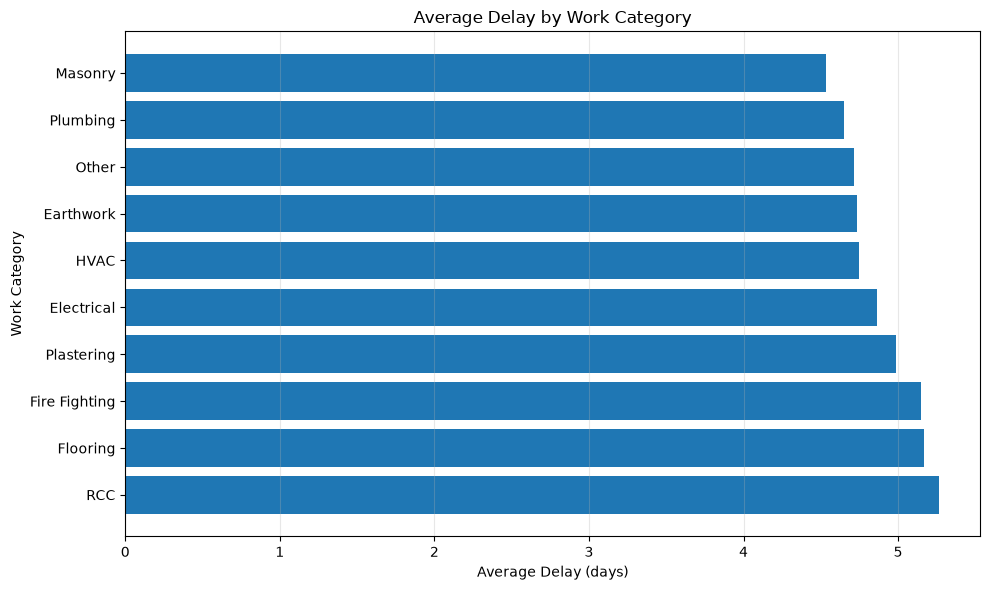

In [56]:
# Average delay by work category

plt.figure(figsize=(10, 6))

plt.barh(
    category_delay["work_category"],
    category_delay["avg_delay_days"]
)

plt.title("Average Delay by Work Category")
plt.xlabel("Average Delay (days)")
plt.ylabel("Work Category")

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    VISUALIZATION_DIR / "work_category_delay.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
# Earned Value Management (EVM) metrics

# Planned Value (PV)
# Budgeted value of work that should have been completed
df["PV_cr"] = df["planned_cost_cr"]

# Earned Value (EV)
# Budgeted value of work that has actually been completed
df["EV_cr"] = (
    df["budget_cr"]
    * df["actual_progress_pct"]
    / 100
)

# Actual Cost (AC)
# Actual expenditure incurred
df["AC_cr"] = df["actual_cost_cr"]

df[
    [
        "project_name",
        "work_category",
        "month",
        "PV_cr",
        "EV_cr",
        "AC_cr"
    ]
].head(10)

,project_name,work_category,month,PV_cr,EV_cr,AC_cr
0,Healthcare Facility,Earthwork,2025-01-01,0.29,0.28,0.30
1,Healthcare Facility,Earthwork,2025-02-01,0.57,0.59,0.60
2,Healthcare Facility,Earthwork,2025-03-01,0.86,0.86,0.92
3,Healthcare Facility,Earthwork,2025-04-01,1.14,1.09,1.20
4,Healthcare Facility,Earthwork,2025-05-01,1.14,1.09,1.16
5,Healthcare Facility,Earthwork,2025-06-01,1.14,1.09,1.18
6,Healthcare Facility,Earthwork,2025-07-01,1.14,1.09,1.18
7,Healthcare Facility,Earthwork,2025-08-01,1.14,1.09,1.21
8,Healthcare Facility,Earthwork,2025-09-01,1.14,1.09,1.21
9,Healthcare Facility,Earthwork,2025-10-01,1.14,1.09,1.19


In [20]:
# Schedule Performance Index (SPI)
# SPI < 1 indicates schedule underperformance

df["SPI"] = np.where(
    df["PV_cr"] > 0,
    df["EV_cr"] / df["PV_cr"],
    np.nan
)

# Cost Performance Index (CPI)
# CPI < 1 indicates cost inefficiency

df["CPI"] = np.where(
    df["AC_cr"] > 0,
    df["EV_cr"] / df["AC_cr"],
    np.nan
)

df[
    [
        "project_name",
        "work_category",
        "month",
        "PV_cr",
        "EV_cr",
        "AC_cr",
        "SPI",
        "CPI"
    ]
].head(10)

,project_name,work_category,month,PV_cr,EV_cr,AC_cr,SPI,CPI
0,Healthcare Facility,Earthwork,2025-01-01,0.29,0.28,0.30,1.00,0.94
1,Healthcare Facility,Earthwork,2025-02-01,0.57,0.59,0.60,1.03,0.98
2,Healthcare Facility,Earthwork,2025-03-01,0.86,0.86,0.92,1.00,0.93
3,Healthcare Facility,Earthwork,2025-04-01,1.14,1.09,1.20,0.96,0.91
4,Healthcare Facility,Earthwork,2025-05-01,1.14,1.09,1.16,0.96,0.94
5,Healthcare Facility,Earthwork,2025-06-01,1.14,1.09,1.18,0.96,0.92
6,Healthcare Facility,Earthwork,2025-07-01,1.14,1.09,1.18,0.96,0.93
7,Healthcare Facility,Earthwork,2025-08-01,1.14,1.09,1.21,0.96,0.90
8,Healthcare Facility,Earthwork,2025-09-01,1.14,1.09,1.21,0.96,0.90
9,Healthcare Facility,Earthwork,2025-10-01,1.14,1.09,1.19,0.96,0.91


In [21]:
# Basic EVM validation

print("PV < 0:", (df["PV_cr"] < 0).sum())
print("EV < 0:", (df["EV_cr"] < 0).sum())
print("AC < 0:", (df["AC_cr"] < 0).sum())

print("SPI missing:", df["SPI"].isna().sum())
print("CPI missing:", df["CPI"].isna().sum())

PV < 0: 0
EV < 0: 0
AC < 0: 0
SPI missing: 145
CPI missing: 145


In [22]:
# Calculate budget-weighted contribution of each work package

df["planned_progress_weighted"] = (
    df["planned_progress_pct"]
    * df["budget_cr"]
)

df["actual_progress_weighted"] = (
    df["actual_progress_pct"]
    * df["budget_cr"]
)

# Aggregate to project-month level
project_progress = (
    df.groupby(
        ["project_name", "contractor", "month"],
        as_index=False
    )
    .agg(
        contract_value_cr=("contract_value_cr", "first"),
        planned_progress_weighted=("planned_progress_weighted", "sum"),
        actual_progress_weighted=("actual_progress_weighted", "sum"),
        planned_cost_cr=("planned_cost_cr", "sum"),
        actual_cost_cr=("actual_cost_cr", "sum"),
        PV_cr=("PV_cr", "sum"),
        EV_cr=("EV_cr", "sum"),
        AC_cr=("AC_cr", "sum"),
        delay_days=("delay_days", "sum")
    )
)

# Convert weighted values into project-level percentages
project_progress["planned_progress_pct"] = (
    project_progress["planned_progress_weighted"]
    / project_progress["contract_value_cr"]
)

project_progress["actual_progress_pct"] = (
    project_progress["actual_progress_weighted"]
    / project_progress["contract_value_cr"]
)

# Remove intermediate columns
project_progress = project_progress.drop(
    columns=[
        "planned_progress_weighted",
        "actual_progress_weighted"
    ]
)

project_progress.head()

,project_name,contractor,month,contract_value_cr,planned_cost_cr,actual_cost_cr,PV_cr,EV_cr,AC_cr,delay_days,planned_progress_pct,actual_progress_pct
0,Administrative Complex,Contractor B,2025-01-01,35.40,1.73,1.81,1.73,1.49,1.81,65,4.88,4.21
1,Administrative Complex,Contractor B,2025-02-01,35.40,3.45,3.64,3.45,2.85,3.64,59,9.75,8.05
2,Administrative Complex,Contractor B,2025-03-01,35.40,5.68,5.95,5.68,5.33,5.95,73,16.05,15.06
3,Administrative Complex,Contractor B,2025-04-01,35.40,8.89,9.11,8.89,8.28,9.11,52,25.11,23.40
4,Administrative Complex,Contractor B,2025-05-01,35.40,12.15,12.94,12.15,10.16,12.94,59,34.33,28.70


In [23]:
# Calculate project-level SPI and CPI

project_progress["SPI"] = np.where(
    project_progress["PV_cr"] > 0,
    project_progress["EV_cr"] / project_progress["PV_cr"],
    np.nan
)

project_progress["CPI"] = np.where(
    project_progress["AC_cr"] > 0,
    project_progress["EV_cr"] / project_progress["AC_cr"],
    np.nan
)

project_progress[
    [
        "project_name",
        "month",
        "PV_cr",
        "EV_cr",
        "AC_cr",
        "SPI",
        "CPI"
    ]
].head(10)

,project_name,month,PV_cr,EV_cr,AC_cr,SPI,CPI
0,Administrative Complex,2025-01-01,1.73,1.49,1.81,0.86,0.82
1,Administrative Complex,2025-02-01,3.45,2.85,3.64,0.83,0.78
2,Administrative Complex,2025-03-01,5.68,5.33,5.95,0.94,0.90
3,Administrative Complex,2025-04-01,8.89,8.28,9.11,0.93,0.91
4,Administrative Complex,2025-05-01,12.15,10.16,12.94,0.84,0.79
5,Administrative Complex,2025-06-01,15.71,14.65,16.19,0.93,0.91
6,Administrative Complex,2025-07-01,20.54,19.02,21.61,0.93,0.88
7,Administrative Complex,2025-08-01,25.38,22.95,26.55,0.90,0.86
8,Administrative Complex,2025-09-01,29.10,25.98,30.16,0.89,0.86
9,Administrative Complex,2025-10-01,32.33,28.98,33.59,0.90,0.86


In [24]:
# Project-level EVM indices

project_progress["SPI"] = np.where(
    project_progress["PV_cr"] > 0,
    project_progress["EV_cr"] / project_progress["PV_cr"],
    np.nan
)

project_progress["CPI"] = np.where(
    project_progress["AC_cr"] > 0,
    project_progress["EV_cr"] / project_progress["AC_cr"],
    np.nan
)

In [25]:
# EVM variance metrics

# Schedule Variance
# Negative = behind schedule
project_progress["SV_cr"] = (
    project_progress["EV_cr"]
    - project_progress["PV_cr"]
)

# Cost Variance
# Negative = over budget
project_progress["CV_cr"] = (
    project_progress["EV_cr"]
    - project_progress["AC_cr"]
)

In [26]:
# Latest EVM performance by project

latest_evm = (
    project_progress
    .sort_values("month")
    .groupby("project_name", as_index=False)
    .tail(1)
    .copy()
)

evm_summary = latest_evm[
    [
        "project_name",
        "contractor",
        "month",
        "PV_cr",
        "EV_cr",
        "AC_cr",
        "SV_cr",
        "CV_cr",
        "SPI",
        "CPI"
    ]
].sort_values("CPI")

evm_summary

,project_name,contractor,month,PV_cr,EV_cr,AC_cr,SV_cr,CV_cr,SPI,CPI
35,Food & Commercial Facility,Contractor A,2025-12-01,9.80,9.13,10.77,-0.67,-1.65,0.93,0.85
11,Administrative Complex,Contractor B,2025-12-01,35.40,32.07,36.52,-3.33,-4.45,0.91,0.88
47,Healthcare Facility,Contractor A,2025-12-01,28.50,27.27,30.83,-1.23,-3.56,0.96,0.88
23,Educational Campus,Contractor C,2025-12-01,18.20,18.20,18.64,0.00,-0.44,1.00,0.98
59,Road Development,Contractor B,2025-12-01,46.75,46.75,47.21,0.00,-0.46,1.00,0.99


In [57]:
# Contractor performance analysis

contractor_performance = (
    evm_summary
    .groupby("contractor", as_index=False)
    .agg(
        avg_SPI=("SPI", "mean"),
        avg_CPI=("CPI", "mean"),
        total_SV_cr=("SV_cr", "sum"),
        total_CV_cr=("CV_cr", "sum"),
        projects=("project_name", "count")
    )
    .sort_values(
        ["avg_SPI", "avg_CPI"],
        ascending=False
    )
)

contractor_performance

,contractor,avg_SPI,avg_CPI,total_SV_cr,total_CV_cr,projects
2,Contractor C,1.00,0.98,0.00,-0.44,1
1,Contractor B,0.95,0.93,-3.33,-4.91,2
0,Contractor A,0.94,0.87,-1.90,-5.21,2


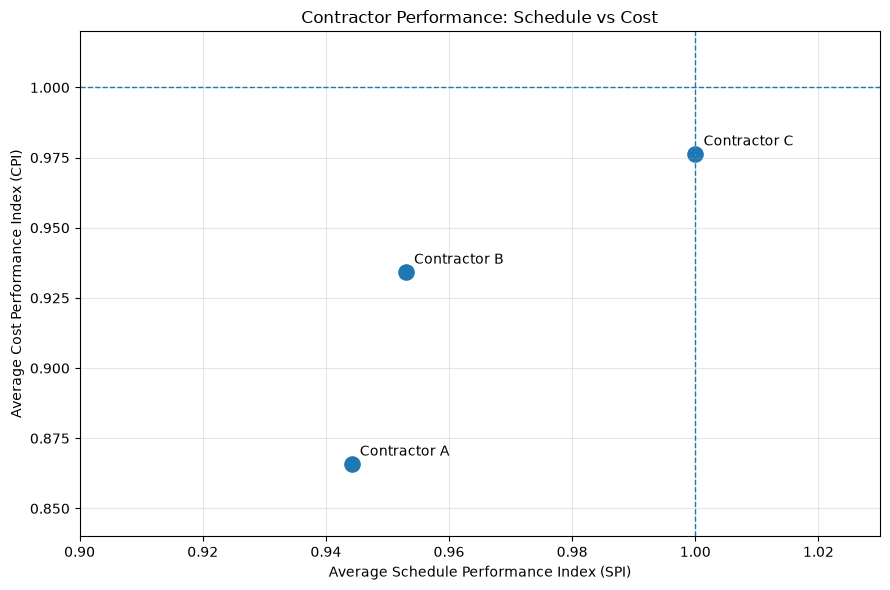

In [59]:
# Contractor performance: SPI vs CPI

plt.figure(figsize=(9, 6))

plt.scatter(
    contractor_performance["avg_SPI"],
    contractor_performance["avg_CPI"],
    s=120
)

# Reference lines
plt.axvline(
    1.0,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    1.0,
    linestyle="--",
    linewidth=1
)

# Label contractors
for _, row in contractor_performance.iterrows():
    plt.annotate(
        row["contractor"],
        (row["avg_SPI"], row["avg_CPI"]),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.xlabel("Average Schedule Performance Index (SPI)")
plt.ylabel("Average Cost Performance Index (CPI)")

plt.title("Contractor Performance: Schedule vs Cost")

plt.xlim(0.90, 1.03)
plt.ylim(0.84, 1.02)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    VISUALIZATION_DIR / "contractor_performance_spi_vs_cpi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
# EVM performance status

evm_summary["schedule_status"] = np.select(
    [
        evm_summary["SPI"] >= 1,
        evm_summary["SPI"] >= 0.95
    ],
    [
        "On/Ahead of Schedule",
        "Minor Schedule Variance"
    ],
    default="Schedule Risk"
)

evm_summary["cost_status"] = np.select(
    [
        evm_summary["CPI"] >= 1,
        evm_summary["CPI"] >= 0.95
    ],
    [
        "On/Under Budget",
        "Minor Cost Variance"
    ],
    default="Cost Risk"
)

evm_summary[
    [
        "project_name",
        "SPI",
        "CPI",
        "SV_cr",
        "CV_cr",
        "schedule_status",
        "cost_status"
    ]
]

,project_name,SPI,CPI,SV_cr,CV_cr,schedule_status,cost_status
35,Food & Commercial Facility,0.93,0.85,-0.67,-1.65,Schedule Risk,Cost Risk
11,Administrative Complex,0.91,0.88,-3.33,-4.45,Schedule Risk,Cost Risk
47,Healthcare Facility,0.96,0.88,-1.23,-3.56,Minor Schedule Variance,Cost Risk
23,Educational Campus,1.00,0.98,0.00,-0.44,On/Ahead of Schedule,Minor Cost Variance
59,Road Development,1.00,0.99,0.00,-0.46,On/Ahead of Schedule,Minor Cost Variance


In [28]:
from pathlib import Path

print(Path.cwd())

/Users/ananthrb/Desktop/construction-project-analytics/notebooks


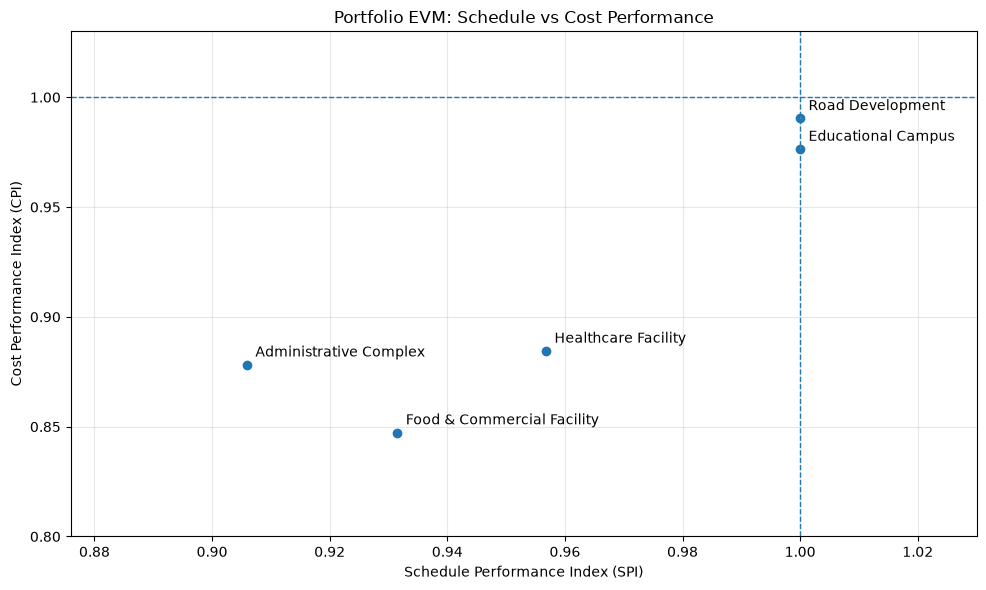

In [29]:
# Portfolio EVM: SPI vs CPI

plt.figure(figsize=(10, 6))

plt.scatter(
    evm_summary["SPI"],
    evm_summary["CPI"]
)

# Reference lines
plt.axvline(
    1.0,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    1.0,
    linestyle="--",
    linewidth=1
)

# Project labels
for _, row in evm_summary.iterrows():
    plt.annotate(
        row["project_name"],
        (row["SPI"], row["CPI"]),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.xlabel("Schedule Performance Index (SPI)")
plt.ylabel("Cost Performance Index (CPI)")

plt.title("Portfolio EVM: Schedule vs Cost Performance")

plt.xlim(
    min(evm_summary["SPI"].min() - 0.03, 0.9),
    1.03
)

plt.ylim(
    min(evm_summary["CPI"].min() - 0.03, 0.8),
    1.03
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    VISUALIZATION_DIR / "portfolio_evm_spi_vs_cpi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
admin_evm = project_progress[
    project_progress["project_name"] == "Administrative Complex"
]

admin_evm[
    [
        "month",
        "PV_cr",
        "EV_cr",
        "AC_cr",
        "SPI",
        "CPI"
    ]
]

,month,PV_cr,EV_cr,AC_cr,SPI,CPI
0,2025-01-01,1.73,1.49,1.81,0.86,0.82
1,2025-02-01,3.45,2.85,3.64,0.83,0.78
2,2025-03-01,5.68,5.33,5.95,0.94,0.90
3,2025-04-01,8.89,8.28,9.11,0.93,0.91
4,2025-05-01,12.15,10.16,12.94,0.84,0.79
5,2025-06-01,15.71,14.65,16.19,0.93,0.91
6,2025-07-01,20.54,19.02,21.61,0.93,0.88
7,2025-08-01,25.38,22.95,26.55,0.90,0.86
8,2025-09-01,29.10,25.98,30.16,0.89,0.86
9,2025-10-01,32.33,28.98,33.59,0.90,0.86


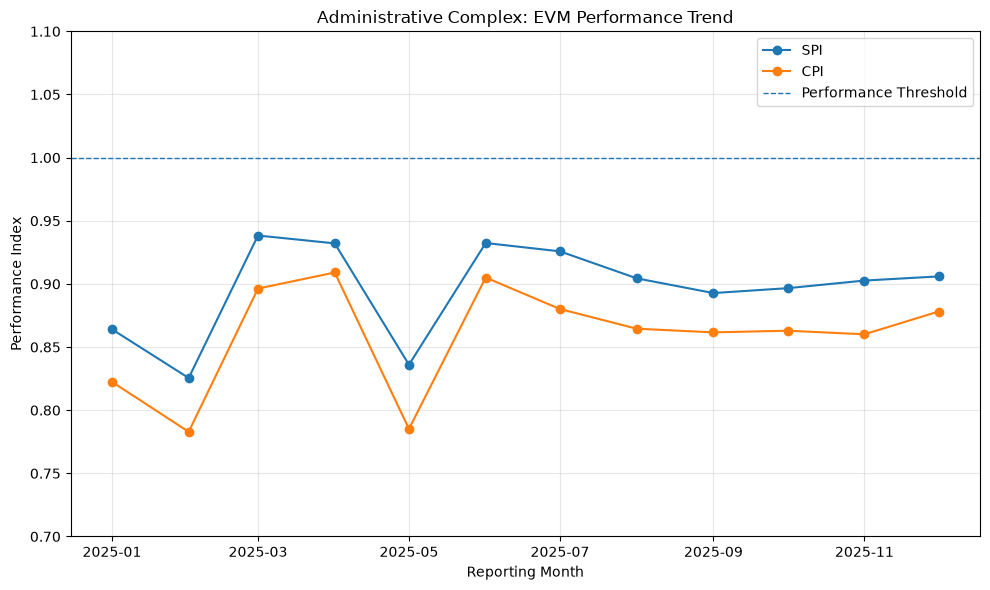

In [31]:
# Administrative Complex: SPI and CPI trend

plt.figure(figsize=(10, 6))

plt.plot(
    admin_evm["month"],
    admin_evm["SPI"],
    marker="o",
    label="SPI"
)

plt.plot(
    admin_evm["month"],
    admin_evm["CPI"],
    marker="o",
    label="CPI"
)

# Performance threshold
plt.axhline(
    1.0,
    linestyle="--",
    linewidth=1,
    label="Performance Threshold"
)

plt.title(
    "Administrative Complex: EVM Performance Trend"
)

plt.xlabel("Reporting Month")
plt.ylabel("Performance Index")

plt.ylim(0.7, 1.1)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    VISUALIZATION_DIR / "administrative_complex_evm_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
# Project-level performance KPIs

project_progress["progress_variance_pct"] = (
    project_progress["actual_progress_pct"]
    - project_progress["planned_progress_pct"]
)

project_progress["cost_variance_cr"] = (
    project_progress["actual_cost_cr"]
    - project_progress["planned_cost_cr"]
)

project_progress["cost_variance_pct"] = np.where(
    project_progress["planned_cost_cr"] > 0,
    (
        project_progress["cost_variance_cr"]
        / project_progress["planned_cost_cr"]
    ) * 100,
    0
)

project_progress["financial_progress_pct"] = (
    project_progress["actual_cost_cr"]
    / project_progress["contract_value_cr"]
) * 100

project_progress["physical_financial_gap_pct"] = (
    project_progress["actual_progress_pct"]
    - project_progress["financial_progress_pct"]
)

project_progress["schedule_status"] = np.where(
    project_progress["progress_variance_pct"] >= 0,
    "On / Ahead",
    "Behind"
)

project_progress.head()

,project_name,contractor,month,contract_value_cr,planned_cost_cr,actual_cost_cr,PV_cr,EV_cr,AC_cr,delay_days,planned_progress_pct,actual_progress_pct,SPI,CPI,SV_cr,CV_cr,progress_variance_pct,cost_variance_cr,cost_variance_pct,financial_progress_pct,physical_financial_gap_pct,schedule_status
0,Administrative Complex,Contractor B,2025-01-01,35.40,1.73,1.81,1.73,1.49,1.81,65,4.88,4.21,0.86,0.82,-0.23,-0.32,-0.66,0.09,5.06,5.12,-0.91,Behind
1,Administrative Complex,Contractor B,2025-02-01,35.40,3.45,3.64,3.45,2.85,3.64,59,9.75,8.05,0.83,0.78,-0.60,-0.79,-1.70,0.19,5.44,10.28,-2.23,Behind
2,Administrative Complex,Contractor B,2025-03-01,35.40,5.68,5.95,5.68,5.33,5.95,73,16.05,15.06,0.94,0.90,-0.35,-0.62,-0.99,0.27,4.69,16.81,-1.74,Behind
3,Administrative Complex,Contractor B,2025-04-01,35.40,8.89,9.11,8.89,8.28,9.11,52,25.11,23.40,0.93,0.91,-0.60,-0.83,-1.70,0.23,2.54,25.74,-2.34,Behind
4,Administrative Complex,Contractor B,2025-05-01,35.40,12.15,12.94,12.15,10.16,12.94,59,34.33,28.70,0.84,0.79,-1.99,-2.78,-5.63,0.79,6.47,36.55,-7.85,Behind


In [33]:
healthcare_progress = project_progress[
    project_progress["project_name"] == "Healthcare Facility"
]

healthcare_progress[
    [
        "month",
        "planned_progress_pct",
        "actual_progress_pct",
        "progress_variance_pct",
        "planned_cost_cr",
        "actual_cost_cr",
        "cost_variance_cr",
        "financial_progress_pct",
        "physical_financial_gap_pct",
        "schedule_status"
    ]
]

,month,planned_progress_pct,actual_progress_pct,progress_variance_pct,planned_cost_cr,actual_cost_cr,cost_variance_cr,financial_progress_pct,physical_financial_gap_pct,schedule_status
36,2025-01-01,4.88,4.53,-0.35,1.39,1.46,0.07,5.13,-0.60,Behind
37,2025-02-01,9.75,9.71,-0.04,2.78,3.04,0.27,10.68,-0.97,Behind
38,2025-03-01,16.05,15.22,-0.84,4.58,4.92,0.35,17.27,-2.05,Behind
39,2025-04-01,25.11,22.60,-2.51,7.16,7.74,0.59,27.17,-4.57,Behind
40,2025-05-01,34.33,32.24,-2.09,9.78,10.33,0.54,36.23,-4.00,Behind
41,2025-06-01,44.38,41.46,-2.92,12.65,13.52,0.87,47.45,-5.99,Behind
42,2025-07-01,58.03,56.67,-1.36,16.54,17.94,1.40,62.94,-6.27,Behind
43,2025-08-01,71.69,67.42,-4.27,20.43,22.08,1.65,77.48,-10.06,Behind
44,2025-09-01,82.22,76.15,-6.06,23.43,25.25,1.82,88.61,-12.45,Behind
45,2025-10-01,91.32,86.61,-4.70,26.03,28.20,2.17,98.95,-12.33,Behind


In [34]:
print(
    "Maximum planned project progress:",
    project_progress["planned_progress_pct"].max()
)

print(
    "Maximum actual project progress:",
    project_progress["actual_progress_pct"].max()
)

Maximum planned project progress: 100.0
Maximum actual project progress: 100.0


In [35]:
print(
    "Minimum actual project progress:",
    project_progress["actual_progress_pct"].min()
)

Minimum actual project progress: 3.4199961764899567


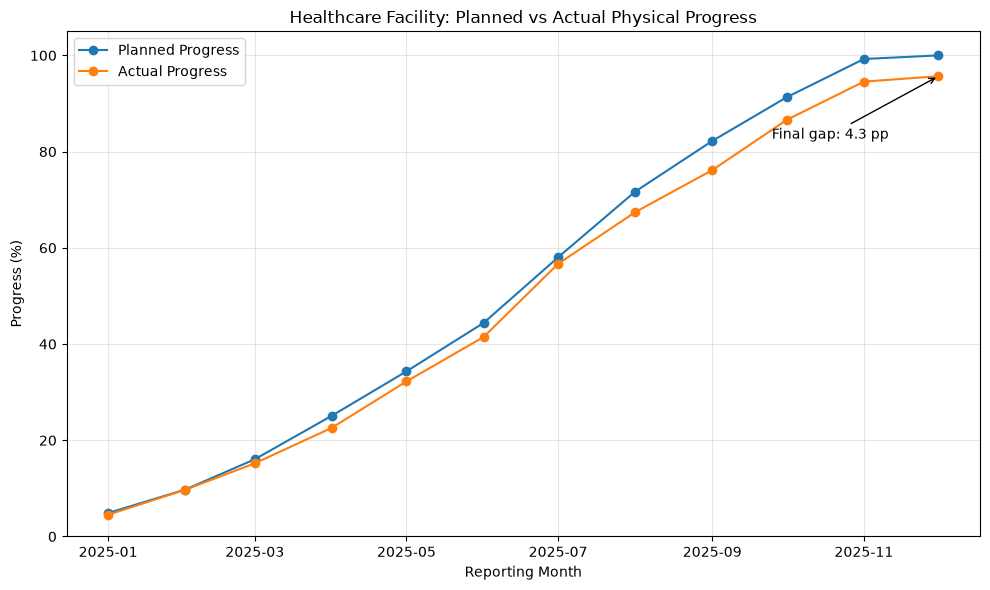

In [36]:
# Plot planned vs actual physical progress
# for the Healthcare Facility

healthcare_progress = (
    project_progress[
        project_progress["project_name"] == "Healthcare Facility"
    ]
    .sort_values("month")
)

plt.figure(figsize=(10, 6))

plt.plot(
    healthcare_progress["month"],
    healthcare_progress["planned_progress_pct"],
    marker="o",
    label="Planned Progress"
)

plt.plot(
    healthcare_progress["month"],
    healthcare_progress["actual_progress_pct"],
    marker="o",
    label="Actual Progress"
)

# Highlight the final progress gap
final_planned = healthcare_progress["planned_progress_pct"].iloc[-1]
final_actual = healthcare_progress["actual_progress_pct"].iloc[-1]

plt.annotate(
    f"Final gap: {final_planned - final_actual:.1f} pp",
    xy=(
        healthcare_progress["month"].iloc[-1],
        final_actual
    ),
    xytext=(-120, -45),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title(
    "Healthcare Facility: Planned vs Actual Physical Progress"
)

plt.xlabel("Reporting Month")
plt.ylabel("Progress (%)")

plt.ylim(0, 105)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    VISUALIZATION_DIR / "healthcare_planned_vs_actual_progress.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
# Get the latest reporting period for each project

latest_month = project_progress["month"].max()

latest_project_performance = (
    project_progress[
        project_progress["month"] == latest_month
    ]
    [
        [
            "project_name",
            "contractor",
            "contract_value_cr",
            "planned_progress_pct",
            "actual_progress_pct",
            "progress_variance_pct",
            "planned_cost_cr",
            "actual_cost_cr",
            "cost_variance_cr",
            "cost_variance_pct",          # Added
            "financial_progress_pct",
            "physical_financial_gap_pct",
            "schedule_status"
        ]
    ]
    .sort_values(
        "progress_variance_pct"
    )
)

latest_project_performance

,project_name,contractor,contract_value_cr,planned_progress_pct,actual_progress_pct,progress_variance_pct,planned_cost_cr,actual_cost_cr,cost_variance_cr,cost_variance_pct,financial_progress_pct,physical_financial_gap_pct,schedule_status
11,Administrative Complex,Contractor B,35.40,100.00,90.59,-9.41,35.40,36.52,1.12,3.17,103.17,-12.57,Behind
35,Food & Commercial Facility,Contractor A,9.80,100.00,93.15,-6.85,9.80,10.77,0.97,9.94,109.94,-16.79,Behind
47,Healthcare Facility,Contractor A,28.50,100.00,95.68,-4.32,28.50,30.83,2.33,8.18,108.18,-12.50,Behind
23,Educational Campus,Contractor C,18.20,100.00,100.00,0.00,18.20,18.64,0.44,2.42,102.42,-2.42,On / Ahead
59,Road Development,Contractor B,46.75,100.00,100.00,0.00,46.75,47.21,0.46,0.98,100.98,-0.98,On / Ahead


In [38]:
print(
    "Projects exceeding 100% actual progress:",
    (
        latest_project_performance["actual_progress_pct"] > 100
    ).sum()
)

Projects exceeding 100% actual progress: 0


In [39]:
"cost_variance_pct" in latest_project_performance.columns

True

In [40]:
# Create a latest-period project scorecard

scorecard = latest_project_performance.copy()

# Schedule performance score
scorecard["schedule_score"] = (
    scorecard["progress_variance_pct"]
    .clip(lower=-20, upper=0)
    + 20
) / 20 * 100

# Cost performance score
scorecard["cost_score"] = (
    100
    - scorecard["cost_variance_pct"].clip(
        lower=0,
        upper=100
    )
)

# Physical vs financial alignment score
scorecard["physical_financial_score"] = (
    100
    + scorecard["physical_financial_gap_pct"].clip(
        lower=-20,
        upper=0
    )
)

# Overall project performance score
scorecard["overall_score"] = (
    scorecard["schedule_score"] * 0.40
    + scorecard["cost_score"] * 0.30
    + scorecard["physical_financial_score"] * 0.30
)

scorecard = scorecard.sort_values(
    "overall_score",
    ascending=False
)

scorecard[
    [
        "project_name",
        "contractor",
        "progress_variance_pct",
        "cost_variance_pct",
        "physical_financial_gap_pct",
        "overall_score"
    ]
]

,project_name,contractor,progress_variance_pct,cost_variance_pct,physical_financial_gap_pct,overall_score
59,Road Development,Contractor B,0.00,0.98,-0.98,99.41
23,Educational Campus,Contractor C,0.00,2.42,-2.42,98.55
47,Healthcare Facility,Contractor A,-4.32,8.18,-12.50,85.15
35,Food & Commercial Facility,Contractor A,-6.85,9.94,-16.79,78.28
11,Administrative Complex,Contractor B,-9.41,3.17,-12.57,76.47


In [41]:
best_project = scorecard.iloc[0]
worst_project = scorecard.iloc[-1]

print("Best performing project:")
print(
    f"{best_project['project_name']} "
    f"({best_project['overall_score']:.1f}/100)"
)

print("\nWorst performing project:")
print(
    f"{worst_project['project_name']} "
    f"({worst_project['overall_score']:.1f}/100)"
)

Best performing project:
Road Development (99.4/100)

Worst performing project:
Administrative Complex (76.5/100)


In [42]:
# Identify the worst-performing project

worst_project_name = worst_project["project_name"]

print(f"Investigating: {worst_project_name}")

Investigating: Administrative Complex


In [43]:
# Work-package performance for the worst-performing project

worst_project_detail = (
    df[
        (df["project_name"] == worst_project_name)
        & (df["month"] == latest_month)
    ]
    [
        [
            "work_category",
            "budget_cr",
            "planned_progress_pct",
            "actual_progress_pct",
            "progress_variance_pct",
            "planned_cost_cr",
            "actual_cost_cr",
            "cost_variance_cr",
            "cost_variance_pct",
            "delay_days"
        ]
    ]
    .sort_values(
        "progress_variance_pct"
    )
)

worst_project_detail

,work_category,budget_cr,planned_progress_pct,actual_progress_pct,progress_variance_pct,planned_cost_cr,actual_cost_cr,cost_variance_cr,cost_variance_pct,delay_days
599,Other,3.19,100.00,85.61,-14.39,3.19,3.25,0.07,2.15,6
563,Plumbing,2.48,100.00,87.22,-12.78,2.48,2.61,0.13,5.22,5
539,Flooring,2.12,100.00,87.46,-12.54,2.12,2.08,-0.04,-1.84,9
551,Electrical,5.31,100.00,89.74,-10.26,5.31,5.61,0.30,5.71,5
575,HVAC,4.25,100.00,91.26,-8.74,4.25,4.54,0.29,6.84,8
527,Plastering,2.48,100.00,91.45,-8.55,2.48,2.45,-0.03,-1.05,6
491,Earthwork,1.42,100.00,91.87,-8.13,1.42,1.42,0.01,0.40,8
503,RCC,8.85,100.00,92.43,-7.57,8.85,9.17,0.32,3.58,5
587,Fire Fighting,1.77,100.00,92.84,-7.16,1.77,1.81,0.04,2.15,1
515,Masonry,3.54,100.00,92.98,-7.02,3.54,3.57,0.03,0.94,7


In [44]:
# Top 5 work packages by schedule underperformance

worst_project_detail[
    [
        "work_category",
        "planned_progress_pct",
        "actual_progress_pct",
        "progress_variance_pct",
        "delay_days"
    ]
].head(5)

,work_category,planned_progress_pct,actual_progress_pct,progress_variance_pct,delay_days
599,Other,100.00,85.61,-14.39,6
563,Plumbing,100.00,87.22,-12.78,5
539,Flooring,100.00,87.46,-12.54,9
551,Electrical,100.00,89.74,-10.26,5
575,HVAC,100.00,91.26,-8.74,8


In [45]:
# Sort work packages by schedule underperformance

driver_analysis = worst_project_detail[
    [
        "work_category",
        "budget_cr",
        "planned_progress_pct",
        "actual_progress_pct",
        "progress_variance_pct",
        "delay_days",
        "planned_cost_cr",
        "actual_cost_cr",
        "cost_variance_cr",
        "cost_variance_pct"
    ]
].copy()

driver_analysis = driver_analysis.sort_values(
    "progress_variance_pct"
)

driver_analysis

,work_category,budget_cr,planned_progress_pct,actual_progress_pct,progress_variance_pct,delay_days,planned_cost_cr,actual_cost_cr,cost_variance_cr,cost_variance_pct
599,Other,3.19,100.00,85.61,-14.39,6,3.19,3.25,0.07,2.15
563,Plumbing,2.48,100.00,87.22,-12.78,5,2.48,2.61,0.13,5.22
539,Flooring,2.12,100.00,87.46,-12.54,9,2.12,2.08,-0.04,-1.84
551,Electrical,5.31,100.00,89.74,-10.26,5,5.31,5.61,0.30,5.71
575,HVAC,4.25,100.00,91.26,-8.74,8,4.25,4.54,0.29,6.84
527,Plastering,2.48,100.00,91.45,-8.55,6,2.48,2.45,-0.03,-1.05
491,Earthwork,1.42,100.00,91.87,-8.13,8,1.42,1.42,0.01,0.40
503,RCC,8.85,100.00,92.43,-7.57,5,8.85,9.17,0.32,3.58
587,Fire Fighting,1.77,100.00,92.84,-7.16,1,1.77,1.81,0.04,2.15
515,Masonry,3.54,100.00,92.98,-7.02,7,3.54,3.57,0.03,0.94


In [46]:
top_schedule_risks = driver_analysis.head(5)

top_schedule_risks[
    [
        "work_category",
        "progress_variance_pct",
        "delay_days",
        "cost_variance_cr",
        "cost_variance_pct"
    ]
]

,work_category,progress_variance_pct,delay_days,cost_variance_cr,cost_variance_pct
599,Other,-14.39,6,0.07,2.15
563,Plumbing,-12.78,5,0.13,5.22
539,Flooring,-12.54,9,-0.04,-1.84
551,Electrical,-10.26,5,0.30,5.71
575,HVAC,-8.74,8,0.29,6.84


In [47]:
top_cost_exposures = (
    driver_analysis
    .sort_values(
        "cost_variance_cr",
        ascending=False
    )
    .head(5)
)

top_cost_exposures[
    [
        "work_category",
        "progress_variance_pct",
        "delay_days",
        "cost_variance_cr",
        "cost_variance_pct"
    ]
]

,work_category,progress_variance_pct,delay_days,cost_variance_cr,cost_variance_pct
503,RCC,-7.57,5,0.32,3.58
551,Electrical,-10.26,5,0.30,5.71
575,HVAC,-8.74,8,0.29,6.84
563,Plumbing,-12.78,5,0.13,5.22
599,Other,-14.39,6,0.07,2.15


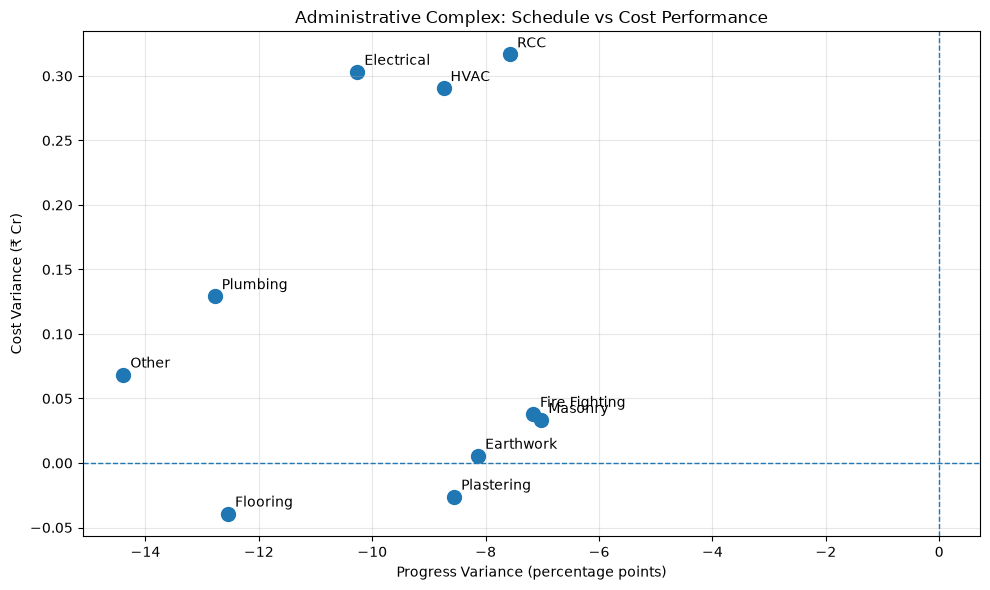

In [48]:
plt.figure(figsize=(10, 6))

plt.scatter(
    driver_analysis["progress_variance_pct"],
    driver_analysis["cost_variance_cr"],
    s=100
)

for _, row in driver_analysis.iterrows():
    plt.annotate(
        row["work_category"],
        (
            row["progress_variance_pct"],
            row["cost_variance_cr"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    f"{worst_project_name}: Schedule vs Cost Performance"
)

plt.xlabel("Progress Variance (percentage points)")
plt.ylabel("Cost Variance (₹ Cr)")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    VISUALIZATION_DIR / "administrative_complex_schedule_vs_cost.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
category_cost_factors

{'Earthwork': 1.02,
 'RCC': 1.06,
 'Masonry': 1.03,
 'Plastering': 1.01,
 'Flooring': 0.99,
 'Electrical': 1.05,
 'Plumbing': 1.04,
 'HVAC': 1.08,
 'Fire Fighting': 1.02,
 'Other': 1.0}

In [50]:
project_performance["Administrative Complex"]

{'progress_factor': 0.88, 'cost_factor': 1.0, 'delay_factor': 1.3}

In [51]:
category_cost_factors

{'Earthwork': 1.02,
 'RCC': 1.06,
 'Masonry': 1.03,
 'Plastering': 1.01,
 'Flooring': 0.99,
 'Electrical': 1.05,
 'Plumbing': 1.04,
 'HVAC': 1.08,
 'Fire Fighting': 1.02,
 'Other': 1.0}

In [52]:
print(VISUALIZATION_DIR.exists())

True


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy

print("Python environment is working!")
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)

Python environment is working!
Pandas: 3.0.5
NumPy: 2.5.2
SciPy: 1.18.0
